# OpenMC-Based Physics-Informed Hybrid GA–Bayesian Optimisation for BWR Fuel Assembly Enrichment Layout

*A memetic GA-scouting-then-BO-refinement workflow for binary-enrichment pin layout design, benchmarked against the Gundremmingen-A BWR 6×6 assembly*

---

## Introduction

This notebook combines the two standalone optimisers explored elsewhere in this study — the Genetic Algorithm (GA) and Bayesian Optimisation (BO) — into a single **hybrid GA–BO** workflow for the same BWR 6×6 fuel-assembly enrichment-layout problem: arranging a fixed inventory of high- and low-enrichment UO₂ rods to bring the assembly's infinite multiplication factor, k∞, close to a target value while keeping the pin-wise Power Peaking Factor (PPF) within a safety limit. The motivation is structural rather than incremental: GA naturally handles the problem's binary, combinatorial chromosome representation, while BO is sample-efficient once it has a good region of the design space to refine — so this notebook lets the GA find that region first, then hands it to BO. The pipeline runs in three phases:

$$\text{GA scouting} \ ––> \text{discrete-to-continuous bridge} \ ––> \text{BO fine-tuning}$$

This three-phase pattern is an instance of what the optimisation literature calls a **memetic algorithm** — a population-based global search (here, the GA) combined with a local refinement procedure (here, GP-based BO) operating on the same objective. Memetic algorithms are well established for exactly this reason: population-based metaheuristics are good at broad exploration but slow to polish a near-optimal solution, while local-search and surrogate-based methods converge quickly once seeded in the right neighbourhood.

The reference case and feasibility criteria are unchanged from the standalone GA and BO notebooks: a fixed inventory of 23 high-enrichment (2.53 wt%) and 13 low-enrichment (1.87 wt%) rods (average enrichment E = 2.292%), a target k∞ ≈ 1.25, and a PPF limit of 1.35, following the Gundremmingen-A BWR 6×6 benchmark used by Radaideh et al. (2021). This notebook is best read as a third, comparative strategy alongside the standalone GA and BO runs — not a replacement for either.

Although the notebook and underlying platform are written generically for an N×N assembly (configurable via `BWR_N` and `N_HIGH_RODS`), every fixed parameter, benchmark comparison, and validated result described below is specific to the N = 6 case. Changing `BWR_N` reframes the problem to a different assembly size and rod inventory that has not been benchmarked or physically validated in this notebook.

---

## 1. Why a Hybrid Approach?

The standalone GA and standalone BO notebooks each have a structural mismatch with part of this problem:

- **GA** explores the discrete chromosome space naturally — crossover, mutation, elitism, and physics-informed repair/masking all operate directly on binary rod assignments — but a population-based search can be slow to fine-tune the last few percent of performance once it has located a good region, since it keeps re-exploring rather than exploiting.
- **BO** is sample-efficient once it has a useful surrogate, but it is built for smooth, continuous objective landscapes. Decoding a continuous BO vector into a binary enrichment layout means a small change in the underlying vector can flip several rods at once, producing the kind of non-smooth, discontinuous response surface that Gaussian Process surrogates struggle to model from a cold start of random samples.

The hybrid approach lets each method do the part it's good at: GA performs **global scouting** over the full discrete space and identifies a set of elite, physically promising layouts; BO then performs **local refinement** around those elites rather than starting from scratch. This is also why the hybrid is framed here as a comparative third strategy — it directly tests whether combining global evolutionary search with surrogate-guided local refinement outperforms either method run independently, under the same OpenMC evaluation budget.

---

## 2. Physical Model and Enrichment Representation

| Chromosome Bit | Fuel Type | U-235 Enrichment |
| :---: | :---: | :---: |
| `0` | Low-enrichment UO₂ | 1.87 wt% |
| `1` | High-enrichment UO₂ | 2.53 wt% |

| Parameter | Value |
| :--- | :---: |
| Assembly size | 6×6 (36 pins) |
| Symmetry-reduced positions | 21 |
| High-enrichment rods (fixed) | 23 |
| Low-enrichment rods (fixed) | 13 |
| Average enrichment E | 2.292 wt% |
| Target k∞ | 1.25 |
| PPF limit | < 1.35 |

As in the standalone notebooks, the inventory split is held fixed throughout both phases — the GA's repair logic and the BO bridge's encoding both preserve exactly 23 high-enrichment rods, so the search is always over *where* those rods sit among the 21 symmetry-reduced positions (each diagonal position representing one physical pin, each off-diagonal position representing a mirrored pair of two), never over how many there are. The OpenMC model represents a single, isolated assembly under reflective boundary conditions, so the eigenvalue returned is the assembly's infinite multiplication factor, k∞, not the full-core effective multiplication factor, k_eff.

---
## 3. Workflow

```
Phase 1 — GA Global Scouting
  Initialise population (inventory + corner mask enforced)
  Run GA for n_generations (short burst — scouting only)
  → OpenMC evaluates each individual -> k∞, PPF, fitness
  Extract top-N unique elite chromosomes
              |
              ▼
Phase 2 — Bridge (Discrete → Continuous)
  Map each elite chromosome to a continuous seed vector
    bit = 1  ->  0.9 + U(−0.05, +0.05)
    bit = 0  ->  0.1 + U(−0.05, +0.05)
  Zero additional OpenMC calls
  Carry k∞, PPF, score forward from Phase 1
              |
              ▼
Phase 3 — BO Fine-Tuning
  Seed GP with elite continuous vectors (replaces random LHS)
  Fit Matérn-5/2 ARD Gaussian Process surrogate
              |
              ▼
  BO Loop (n_bo_iterations)
    Score 80,000 candidates via GP (no OpenMC)
    Select candidate with highest Expected Improvement
    Decode -> Run OpenMC -> collect k∞, PPF, score
    Update GP with new result
              |
              ▼
  Return best design across Phase 1 + Phase 3
```
---

## 4. Score and Fitness Functions

Both phases share the same underlying physics objective, expressed in each stage's native convention. The GA (Phase 1) minimises a fitness score; the BO bridge and Phase 3 (via `composite_score`) work with the equivalent maximised score:

$$F_{\text{GA}} = \alpha_k \left| k_{\text{target}} - k_{\infty} \right| + \alpha_{\text{PPF}} \max\left(0,\ \text{PPF} - \text{PPF}_{\text{target}}\right)^2 + w_{\text{adj}} \cdot N_{\text{adj}}$$

$$\text{Score}_{\text{BO}} = -\alpha_k \left| k_{\text{target}} - k_{\infty} \right| - \alpha_{\text{PPF}} \max\left(0,\ \text{PPF} - \text{PPF}_{\text{target}}\right)^2$$

Using the same $\alpha_k$ and $\alpha_{\text{PPF}}$ weights in both phases keeps the GA's notion of a "good" layout and the BO surrogate's notion of a "good" layout aligned, so Phase 3 genuinely refines what Phase 1 found promising rather than optimising a subtly different objective.

---

## 5. Physics-Informed Constraints

The same two optional heuristics used in the standalone notebooks apply identically in both phases here:

- **Corner masking (hard constraint).** Prevents high-enrichment rods from occupying the four corner positions, since corner pins sit at the assembly boundary where neutron leakage is highest — keeping them low-enrichment reduces leakage and helps flatten the power distribution.
- **Adjacency penalty (soft constraint).** Penalises directly adjacent high-enrichment pairs to discourage — without strictly forbidding — clustering that would otherwise create local power hot spots.

Both constraints act on the GA's chromosome representation directly in Phase 1, and persist into Phase 3 through the bridged continuous seeds and the shared scoring weights.

---

## 6. Limitations

This notebook is a proof-of-concept comparison of optimisation strategies, **not** a licensed fuel-design tool. Beyond the limitations already inherited from the standalone GA and BO notebooks — no depletion, thermal-hydraulic feedback, control rods, axial effects, or finite-core leakage; k∞ rather than full-core k_eff; Monte Carlo statistical noise at the particle counts used during search — the hybrid approach introduces its own:

- **Added algorithmic complexity.** Two optimisers, a bridging step, and shared configuration must all stay consistent (same physics targets, same penalty weights) for the comparison to be meaningful.
- **Sensitivity to elite quality and diversity.** Phase 3 can only refine what Phase 1 finds. If the GA's short scouting run converges prematurely or its elite set lacks diversity, BO will faithfully refine a narrow, potentially suboptimal region rather than the global best.
- **Discrete-to-continuous mapping artifacts.** The bridge's anchor values and jitter are a deliberate engineering choice to stabilise the GP fit, not a physically derived mapping — different anchor or noise choices could plausibly shift how well BO exploits the GA's seeds.
- **Compounded Monte Carlo noise.** Statistical noise affects both the GA's fitness ranking in Phase 1 and the GP surrogate's training data in Phase 3, so noise introduced early in scouting can propagate into which regions BO is seeded to refine.

As with the standalone notebooks, the best layout this hybrid method finds should be treated as a promising candidate requiring higher-fidelity OpenMC validation and further reactor-physics analysis — not a final or guaranteed-optimal design.

# User Inputs
**(Change only `BWR_N` and `N_HIGH_RODS` to switch assembly size.)**

In [1]:
BWR_N        = 6    # –––––> Side length of the square assembly
N_HIGH_RODS  = 23   # –––––> Number of high-enrichment rods in the
                    #   full N×N grid (assembly-specific physics input)

import os
##****** Toggles: Both true ––> toggles turned on; Both False ––> turned off **********#####

ENABLE_CORNER_MASKING = True  #True or False         
ENABLE_ADJACENCY_PENALTY = True      #True or False  

ENABLE_ADJACENCY_PENALTY_WEIGHT = 2.0

ALPHAK = 5
ALPHAPPF = 10


'''
 Heuristic Constraints:
     Corner masking reduces the effective search space, while the adjacency penalty discourages clustered high-enrichment rods. 
     Since the soft penalty can increase selection pressure, the GA population is increased only mildly to preserve diversity.

 Assembly Size:
     For an N×N assembly, chromosome length scales approximately with N^2, while the number of possible enrichment layouts grows combinatorially. 
     Larger assemblies may therefore require larger GA and BO budgets.
    
'''


use_physics_heuristics = ENABLE_CORNER_MASKING or ENABLE_ADJACENCY_PENALTY


# GA scouting budget
base_ga_pop = int(20 * (BWR_N / 6))   # 20 for 6×6
base_ga_gen = int(10 * (BWR_N / 6))   # 10 for 6×6

GA_POPULATION_SIZE = int(base_ga_pop * 1.1) if use_physics_heuristics else base_ga_pop
GA_GENERATIONS     = base_ga_gen


N_ELITE = 10 #–––––––––––> Number of GA elite layouts passed to BO
N_LHS_EXTRA = 10


# BO refinement iterations after the GA elite seed set.
base_bo_iter = int(25 * (BWR_N / 6))  # 25 for 6×6
BO_ITERATIONS      = int(base_bo_iter * 1.2) if use_physics_heuristics else base_bo_iter



# Auto-derived — do not edit
N_TOTAL     = BWR_N ** 2
N_SYM       = BWR_N * (BWR_N + 1) // 2

suffix = "HP-GA-BO" if use_physics_heuristics else "GA-BO"
MODEL_NAME   = f"BWR_{BWR_N}x{BWR_N}_{suffix}"
RESULTS_DIR = f"../Results/{MODEL_NAME}"



print(f"HO-BO Setup complete: {MODEL_NAME}")

HO-BO Setup complete: BWR_6x6_HP-GA-BO


# Imports

In [2]:

import sys, os, warnings
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.makedirs(RESULTS_DIR, exist_ok=True)

from openmc_ga import GAConfig, run_ga, summarise_ga_results
from openmc_bo import RunConfig, run_bo, summarise_results, plot_convergence

from environments.env        import evaluate_for_ga, evaluate_for_bo, get_model_params
from environments.bwr_vis    import plot_enr_grid
from environments.bwr_report import export_design_report


print("All imports successful.")

All imports successful.


# Configurations

In [3]:

cfg_ga = GAConfig(
    n_rods_side  = BWR_N,
    n_high_rods  = N_HIGH_RODS,

    # Physics-informed constraints
    k_target     = 1.25,
    ppf_target   = 1.35,
    alpha_k           = ALPHAK,   
    alpha_ppf         = ALPHAPPF,
   
    use_corner_masking    = ENABLE_CORNER_MASKING,
    use_adjacency_penalty = ENABLE_ADJACENCY_PENALTY,
    adj_penalty_weight    = ENABLE_ADJACENCY_PENALTY_WEIGHT,

    # GA hyper-parameters
    population_size  = GA_POPULATION_SIZE,
    n_generations    = GA_GENERATIONS,   # short burst — scouting only
    crossover_rate   = 0.85,
    mutation_rate    = 0.15,
    n_swaps_per_mut  = 2,
    tournament_size  = 3,
    elitism_count    = 2,
    random_seed      = 42,
   
    n_particles      = 5000,  #5000
    n_inactive       = 20,
    n_active         = 40,
    
    n_particles_smoke= 500,    #500
    n_inactive_smoke = 10,
    n_active_smoke   = 15,
    model_name       = MODEL_NAME,
    results_dir      = RESULTS_DIR,
)

cfg_bo = RunConfig(
    n_rods_side       = BWR_N,
    n_high_rods       = N_HIGH_RODS,

    # Physics-informed constraints
    k_target          = 1.25,
    ppf_target        = 1.35,
   
    alpha_k           = ALPHAK,   
    alpha_ppf         = ALPHAPPF,   
    use_corner_masking    = ENABLE_CORNER_MASKING,
    use_adjacency_penalty = ENABLE_ADJACENCY_PENALTY,
    adj_penalty_weight    = ENABLE_ADJACENCY_PENALTY_WEIGHT,
    
    #BO hyper-parameters
    n_initial_samples = N_ELITE,   
    n_bo_iterations   = BO_ITERATIONS,
    n_candidates      = 80000,
    ei_xi             = 0.01,
    gp_restarts       = 10,
    random_seed       = 42,
    
    #Openmc Settinggs
    n_particles       = 5000,  #5000
    n_inactive        = 20,
    n_active          = 40,
    
    n_particles_smoke = 500,   #500
    n_inactive_smoke  = 10,
    n_active_smoke    = 15,
    model_name        = MODEL_NAME,
    results_dir       = RESULTS_DIR,
)

evaluate_fn_ga = partial(evaluate_for_ga, cfg=cfg_ga)
evaluate_fn_bo = partial(evaluate_for_bo, cfg=cfg_bo)

print("GA Configuration")
print("="*70)
print(cfg_ga.summary())
print("="*70)
print()
print("BO Configuration")
print("="*70)
print(cfg_bo.summary())
print("="*70)

GA Configuration
GAConfig — BWR_6x6_HO_BO
  Assembly           : 6×6 = 36 pins
  Chromosome length  : 21  (1/2-diagonal symmetry)
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36
  k-inf target       : 1.25  (alpha_k = 5)
  PPF target         : 1.35  (alpha_ppf = 10)
  Corner masking     : True (hard mask — no weight)
  Adjacency penalty  : True  (weight=2.0)
  Population size    : 22
  Generations        : 10
  Crossover rate     : 0.85
  Mutation rate      : 0.15  (2 swap(s)/event)
  Tournament size    : 3
  Elitism count      : 2
  Random seed        : 42
  OpenMC particles   : 5000  (20 inactive + 40 active)
  Smoke particles    : 500  (10 inactive + 15 active)
  Results dir        : ../Results/BWR_6x6_HO_BO

BO Configuration
RunConfig — BWR_6x6_HO_BO
  Assembly           : 6×6 = 36 pins
  Design variables   : 21  
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36
  k-inf target       : 1.25 

# Phase 1: GA Global Scouting

In [4]:

print(f"Phase 1 — GA scouting  [{BWR_N}×{BWR_N}, {N_SYM}-bit chromosomes]")

ga_data = run_ga(
    cfg_ga, evaluate_fn_ga,
    verbose              = True,
    selection            = "tournament",
    crossover_method     = "two_point",
    convergence_patience = cfg_ga.n_generations + 1,
)

# De-duplicate and extract top-N_ELITE chromosomes
all_chroms  = ga_data["all_chromosomes"]
all_fitness = ga_data["all_fitness"]
all_keff    = ga_data["all_keff"]
all_ppf     = ga_data["all_ppf"]

seen, elite_idx = set(), []
for i in np.argsort(all_fitness):
    key = tuple(all_chroms[i])
    if key not in seen:
        seen.add(key)
        elite_idx.append(i)
    if len(elite_idx) == N_ELITE:
        break

elite_chroms  = all_chroms[elite_idx]
elite_fitness = all_fitness[elite_idx]
elite_keff    = all_keff[elite_idx]
elite_ppf     = all_ppf[elite_idx]

print(f"\nTop-{N_ELITE} unique elites extracted:")

for rank, (fit, k, p) in enumerate(zip(elite_fitness, elite_keff, elite_ppf), 1):
    ppf_status = "PPF target met" if p <= cfg_ga.ppf_target else "PPF target exceeded"

    print(
        f"  {rank:2d}. fitness={fit:.5f}  k∞={k:.5f}  "
        f"PPF={p:.4f}  {ppf_status}"
    )

Phase 1 — GA scouting  [6×6, 21-bit chromosomes]
Population initialised  [6×6 assembly]
  22 individuals  ×  21 bits/chromosome
  Inventory : 23 × 2.53%  +  13 × 1.87%  → avg 2.2917 wt%
  Valid (d,o) pairs : [(1, 11), (3, 10)]
  Constraints OK    : OK

GAConfig — BWR_6x6_HO_BO
  Assembly           : 6×6 = 36 pins
  Chromosome length  : 21  (1/2-diagonal symmetry)
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36
  k-inf target       : 1.25  (alpha_k = 5)
  PPF target         : 1.35  (alpha_ppf = 10)
  Corner masking     : True (hard mask — no weight)
  Adjacency penalty  : True  (weight=2.0)
  Population size    : 22
  Generations        : 10
  Crossover rate     : 0.85
  Mutation rate      : 0.15  (2 swap(s)/event)
  Tournament size    : 3
  Elitism count      : 2
  Random seed        : 42
  OpenMC particles   : 5000  (20 inactive + 40 active)
  Smoke particles    : 500  (10 inactive + 15 active)
  Results dir        : ../Results/BWR_6x6_HO

Gen   1:   0%|          | 0/22 [00:00<?, ?it/s]

  Gen   1/10:  best_fit=36.10102  k∞=1.27020 ±0.00236  PPF=1.1031  feas=22/22  div=0.336  [HOF fit=36.10102]
Generations:  10%|██▊                         | 1/10 [08:54<1:20:11, 534.62s/it]

Gen   2:   0%|          | 0/22 [00:00<?, ?it/s]

  Gen   2/10:  best_fit=36.10102  k∞=1.27020 ±0.00236  PPF=1.1031  feas=22/22  div=0.307  [HOF fit=36.10102]
Generations:  20%|█████▌                      | 2/10 [17:59<1:12:05, 540.73s/it]

...

  Gen   9/10:  best_fit=36.10102  k∞=1.27020 ±0.00236  PPF=1.1031  feas=22/22  div=0.089  [HOF fit=36.10102]
Generations:  90%|█████████████████████████▏  | 9/10 [1:22:17<09:14, 554.07s/it]

Gen  10:   0%|          | 0/22 [00:00<?, ?it/s]

  Gen  10/10:  best_fit=36.10102  k∞=1.27020 ±0.00236  PPF=1.1031  feas=22/22  div=0.034  [HOF fit=36.10102]
Generations: 100%|███████████████████████████| 10/10 [1:31:44<00:00, 550.43s/it]

  Final population evaluation-


Gen  10:   0%|          | 0/22 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════════
  GA SUMMARY — BWR_6x6_HO_BO  [6×6]
══════════════════════════════════════════════════════════════════════
  Best k∞            : 1.27020 ± 0.00236
  k∞ target          : 1.25
  |Δk∞|              : 0.02020  (2020.3 pcm)
  PPF                : 1.1031  (limit ≤ 1.35)  SATISFIED
  Best fitness       : 36.101016
  Total OpenMC calls : 242
  Best chromosome    : [0 1 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 0]
══════════════════════════════════════════════════════════════════════

Top-10 unique elites extracted:
   1. fitness=36.10102  k∞=1.27020  PPF=1.1031  PPF target met
   2. fitness=36.10176  k∞=1.27035  PPF=1.1127  PPF target met
   3. fitness=36.10395  k∞=1.27079  PPF=1.1084  PPF target met
   4. fitness=36.10796  k∞=1.27159  PPF=1.1289  PPF target met
   5. fitness=40.07601  k∞=1.26520  PPF=1.1292  PPF target met
   6. fitness=40.09018  k∞=1.26804  PPF=1.1234  PPF target met
   7. fitness=40.09041  k∞=1.26808  PPF=1.1065 

# Phase 2: Bridge (discrete → continuous)

In [5]:
def bridge_ga_to_bo(
    elite_chroms, elite_keff, elite_ppf, cfg_bo,
    rng, hi_value=0.9, lo_value=0.1, noise_range=0.05,
):


    '''
    Translate GA elite binary chromosomes into continuous [0,1]^n_vars seed vectors that can be used by the BO Gaussian Process.

    This acts as a discrete-to-continuous bridge between the GA and BO stages.

    Works for any chromosome length — no hardcoded dimensions.

    Mapping:
        bit = 1  -> hi_value + U(-noise_range, +noise_range)
        bit = 0  -> lo_value + U(-noise_range, +noise_range)

    The small random noise separates similar elite chromosomes in continuous space, which helps avoid duplicate BO inputs and 
    near-singular GP covariance matrices.

    No additional OpenMC calls are made here. The function reuses the k∞ and PPF values already obtained during the GA evaluation stage.
    
    '''

    
    n_elite, n_vars = elite_chroms.shape
    assert n_vars == cfg_bo.n_vars, (
        f"Chromosome length {n_vars} does not match "
        f"cfg_bo.n_vars={cfg_bo.n_vars}. Check BWR_N and N_HIGH_RODS."
    )

    X_cont = np.where(elite_chroms == 1, hi_value, lo_value).astype(float)
    noise  = rng.uniform(-noise_range, noise_range, size=(n_elite, n_vars))
    X_cont = np.clip(X_cont + noise, 0.0, 1.0)

    scores = np.array([
        cfg_bo.composite_score(k, p)
        for k, p in zip(elite_keff, elite_ppf)
    ])

    print(f"  Bridge: {n_elite} × {n_vars}-dim continuous seeds  "
          f"[{BWR_N}×{BWR_N} assembly]")
    for i in range(n_elite):
        x_str = "  ".join(f"{v:.3f}" for v in X_cont[i, :4])
        print(f"  {i+1:2d}. [{x_str}]  score={scores[i]:.5f}")

    return dict(
        X        = X_cont,
        keff     = elite_keff.copy(),
        keff_std = np.zeros(n_elite),
        ppf      = elite_ppf.copy(),
        score    = scores,
    )


print("Phase 2 — Bridge")
bo_smart_seeds = bridge_ga_to_bo(
    elite_chroms, elite_keff, elite_ppf, cfg_bo,
    rng         = np.random.default_rng(seed=99),
    hi_value    = 0.9,
    lo_value    = 0.1,
    noise_range = 0.05,
)

print(f"\n {len(bo_smart_seeds['X'])} seeds ready for BO  "
      f"(0 extra OpenMC calls)")

Phase 2 — Bridge
  Bridge: 10 × 21-dim continuous seeds  [6×6 assembly]
   1. [0.101  0.907  0.101  0.947]  score=-0.10102
   2. [0.120  0.895  0.139  0.094]  score=-0.10176
   3. [0.119  0.907  0.127  0.112]  score=-0.10395
   4. [0.077  0.912  0.889  0.075]  score=-0.10796
   5. [0.076  0.941  0.900  0.134]  score=-0.07601
   6. [0.078  0.900  0.085  0.927]  score=-0.09018
   7. [0.082  0.906  0.947  0.060]  score=-0.09041
   8. [0.074  0.856  0.125  0.887]  score=-0.09118
   9. [0.127  0.945  0.091  0.920]  score=-0.09965
  10. [0.102  0.886  0.921  0.925]  score=-0.10185

 10 seeds ready for BO  (0 extra OpenMC calls)


# Phase 3: BO Fine-Tuning

Phase 3 — BO fine-tuning  [6×6, 21-D space]
GP surrogate — 10 training points
  Kernel : 0.959**2 * Matern(length_scale=[10, 1.78, 7.12, 10, 0.507, 10, 10, 10, 0.609, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], nu=2.5) + WhiteKernel(noise_level=9.92e-06)
  Log-marginal-likelihood : -11.8268

Running 30 BO iterations …
Objective : − 5·|1.25 − k∞| − 10·max(0, PPF − 1.35)²



BO iterations:   0%|          | 0/30 [00:00<?, ?it/s]

  BO  1 [total=11]:  k∞=1.27084 ±0.00242  |Δk|=0.02084  PPF=1.132  score=-52.10420  best=-0.07601
  BO  2 [total=12]:  k∞=1.26858 ±0.00230  |Δk|=0.01858  PPF=1.138  score=-48.09289  best=-0.07601
  BO  3 [total=13]:  k∞=1.27270 ±0.00180  |Δk|=0.02270  PPF=1.126  score=-52.11349  best=-0.07601
  BO  4 [total=14]:  k∞=1.27278 ±0.00209  |Δk|=0.02278  PPF=1.113  score=-44.11390  best=-0.07601
  BO  5 [total=15]:  k∞=1.27201 ±0.00202  |Δk|=0.02201  PPF=1.111  score=-52.11003  best=-0.07601
  BO  6 [total=16]:  k∞=1.26871 ±0.00228  |Δk|=0.01871  PPF=1.104  score=-48.09356  best=-0.07601
  BO  7 [total=17]:  k∞=1.27399 ±0.00202  |Δk|=0.02399  PPF=1.122  score=-48.11993  best=-0.07601
  BO  8 [total=18]:  k∞=1.26777 ±0.00223  |Δk|=0.01777  PPF=1.106  score=-44.08885  best=-0.07601
  BO  9 [total=19]:  k∞=1.27160 ±0.00198  |Δk|=0.02160  PPF=1.127  score=-48.10798  best=-0.07601
  BO 10 [total=20]:  k∞=1.27179 ±0.00192  |Δk|=0.02179  PPF=1.120  score=-48.10897  best=-0.07601
  BO 11 [total=21]: 

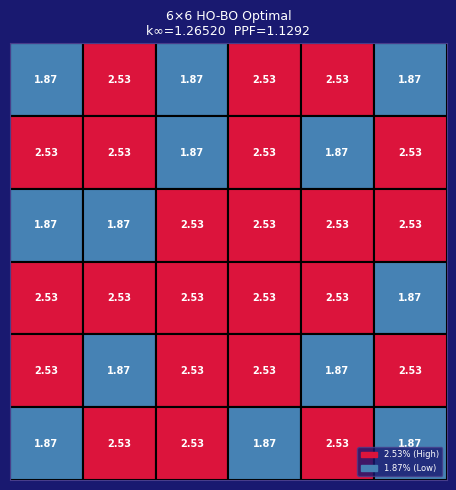

Grid saved → ../Results/BWR_6x6_HO_BO/BWR_6x6_HO_BO_optimal_grid.png

Total OpenMC calls: 220 (GA) + 30 (BO) = 250


In [6]:

print(f"Phase 3 — BO fine-tuning  [{BWR_N}×{BWR_N}, {cfg_bo.n_vars}-D space]")

bo_data = run_bo(
    cfg_bo, evaluate_fn_bo, bo_smart_seeds, verbose=True
)

best_hobo    = summarise_results(cfg_bo, bo_data, save=True, verbose=True)
enr_grid_opt = cfg_bo.decode(best_hobo["x"])

# Save optimal grid 
fig_grid, ax = plt.subplots(1, 1, figsize=(5, 5))
fig_grid.patch.set_facecolor("midnightblue")
plot_enr_grid(
    enr_grid_opt,
    title = (f"{BWR_N}×{BWR_N} HO-BO Optimal\n"
             f"k∞={best_hobo['keff']:.5f}  PPF={best_hobo['ppf']:.4f}"),
    ax    = ax,
)
plt.tight_layout()
grid_path = f"{RESULTS_DIR}/{MODEL_NAME}_optimal_grid.png"
fig_grid.savefig(grid_path, dpi=150, bbox_inches="tight", facecolor="midnightblue")
plt.show()
print(f"Grid saved -> {grid_path}")

ga_calls = cfg_ga.population_size * cfg_ga.n_generations
bo_calls = cfg_bo.n_bo_iterations
print(f"\nTotal OpenMC calls: {ga_calls} (GA) + {bo_calls} (BO) "
      f"= {ga_calls + bo_calls}")

# Convergence plot + report

Convergence plot saved → ../Results/BWR_6x6_HO_BO/BWR_6x6_HO_BO_bo_convergence.png


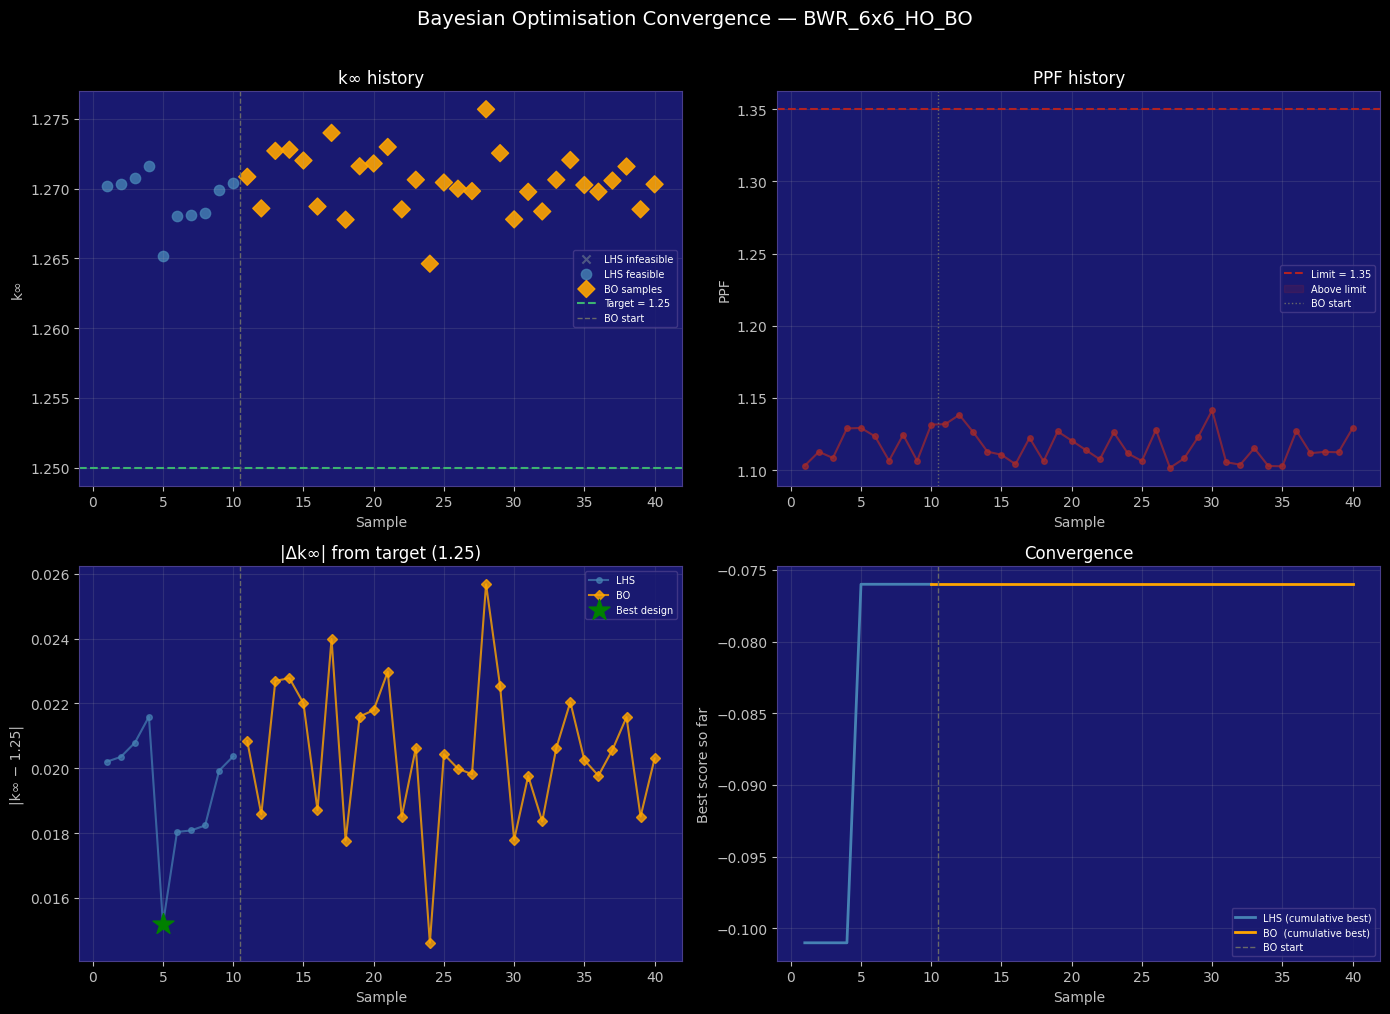

  OPTIMAL 6×6 ENRICHMENT LAYOUT (HP-BO) — BWR_6x6_HO_BO
  Algorithm             : HP-BO
  Assembly size         : 6×6 = 36 fuel pins
  Symmetric positions   : 21  (1/2-diagonal symmetry)
  Enrichment options    : 1.87% (Low)  /  2.53% (High)
  High-enrichment rods  : 23 / 36
  Low-enrichment rods   : 13  / 36
  Average enrichment    : 2.2917 wt%
  k∞                    : 1.26520
  k∞ target             : 1.25
  |Δk∞|                 : 0.01520  (1520.1 pcm)
  PPF                   : 1.1292  (limit ≤ 1.35)
  PPF constraint        : SATISFIED 
  Composite score       : -0.076007

  HP-BO PARAMETERS
  LHS samples           : 10
  BO iterations         : 30
  Candidate pool        : 80000
  EI xi                 : 0.01
  GP restarts           : 10
  Random seed           : 42
  Corner masking        : True
  Adjacency penalty     : True  (weight=2.0)

  GEOMETRY & MATERIAL PARAMETERS
  Layout              : 6 × 6 = 36 fuel pins
  Pin pitch           : 1.62 cm
  Assembly side       : 9.7200 

'../Results/BWR_6x6_HO_BO/optimised_enrichment_layout_hp-bo.txt'

In [7]:

fig_conv = plot_convergence(cfg_bo, bo_data, save=True)
plt.show()

export_design_report(
    cfg          = cfg_bo,
    result_data  = best_hobo,
    enr_grid_opt = enr_grid_opt,
    model_params = get_model_params(BWR_N),
    algorithm    = "HP-BO",
)